In [3]:

import xgboost as xgb
import pandas as pd 
import sklearn as sk
import joblib

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack,csr_matrix
from sklearn.model_selection import train_test_split
#pre processing step 2

filepath = r"C:\Users\lexwo\Downloads\cleaned_with_text.csv"
df1 = pd.read_csv(filepath)
df1["garage"] = df1['garage'].fillna(0) #assume missing garage means no garage

X_train, X_temp, Y_train, Y_temp = train_test_split(df1.drop(columns=["listPrice"]), df1["listPrice"], test_size=0.3, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# 2. Fit scaler on training set only, then transform all splits
scaler = MinMaxScaler()
num_cols = ["sqft","stories","beds","baths","baths_full","baths_full_calc","year_built","garage"]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 3. Fit vectoriser on training text only, then transform all splits
vectorizer = TfidfVectorizer(max_features=1000)
train_text = vectorizer.fit_transform(X_train["text"])
val_text = vectorizer.transform(X_val["text"])
test_text = vectorizer.transform(X_test["text"])

# 4. Combine structured and text features
train_structured = csr_matrix(X_train.drop(columns=["text"]))
val_structured = csr_matrix(X_val.drop(columns=["text"]))
test_structured = csr_matrix(X_test.drop(columns=["text"]))

X_train_final = hstack([train_structured, train_text])
X_val_final = hstack([val_structured, val_text])
X_test_final = hstack([test_structured, test_text])


In [3]:
from xgboost import XGBRegressor
import optuna

def run_trial(result, params, X_train, Y_train, X_val, Y_val):
    model = XGBRegressor(**params, early_stopping_rounds=50, eval_metric=['rmse', 'mae'])
    model.fit(X_train, Y_train, eval_set=[(X_train, Y_train), (X_val, Y_val)], verbose=False)
    results = model.evals_result()
    best_iter = model.best_iteration
    result['val_rmse']   = results['validation_1']['rmse'][best_iter]
    result['val_mae']    = results['validation_1']['mae'][best_iter]
    result['train_rmse'] = results['validation_0']['rmse'][best_iter]
    del model, results

def objective(trial):
    max_features = trial.suggest_int('max_features', 50, 4000, step=50)
    structured = csr_matrix(df1.drop(columns=["listPrice","text"]))
    y = df1["listPrice"]
    
    X_train_idx, X_temp_idx, Y_train, Y_temp = train_test_split(
        range(len(df1)), y, test_size=0.3, random_state=42
    )
    X_val_idx, X_test_idx, Y_val, Y_test = train_test_split(
        X_temp_idx, Y_temp, test_size=0.5, random_state=42
    )
    vectorizer = TfidfVectorizer(max_features=max_features)
    train_text = vectorizer.fit_transform(df1.iloc[X_train_idx]["text"])
    val_text = vectorizer.transform(df1.iloc[X_val_idx]["text"])
    test_text = vectorizer.transform(df1.iloc[X_test_idx]["text"])
    
    train_structured = csr_matrix(structured[X_train_idx])
    val_structured = csr_matrix(structured[X_val_idx])
    test_structured = csr_matrix(structured[X_test_idx])
    
    X_train = hstack([train_structured, train_text])
    X_val = hstack([val_structured, val_text])
    X_test = hstack([test_structured, test_text])
    params = {
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 0.5),
        'random_state': 42,
        'booster': 'gbtree',
        'device': 'cuda',
        'max_bin': 1028,
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'max_delta_step': trial.suggest_float('max_delta_step', 0.0, 10.0)
    }
    model = XGBRegressor(**params, early_stopping_rounds=50, eval_metric=['rmse', 'mae'])
    model.fit(X_train, Y_train, eval_set=[(X_train, Y_train), (X_val, Y_val)], verbose=False)
    results = model.evals_result()
    best_iter = model.best_iteration
    val_rmse   = results['validation_1']['rmse'][best_iter]
    val_mae    = results['validation_1']['mae'][best_iter]
    train_rmse = results['validation_0']['rmse'][best_iter]
    trial.set_user_attr('val_rmse', val_rmse)
    trial.set_user_attr('val_mae', val_mae)
    trial.set_user_attr('train_rmse', train_rmse)
    return val_rmse


storage = "sqlite:///optuna.db"
study = optuna.create_study(direction='minimize', storage=storage, study_name='xgb_studyv2', load_if_exists=True)
study.optimize(objective, n_trials=2000,)
best_trial = study.best_trial

[I 2026-03-27 00:32:55,313] Using an existing study with name 'xgb_studyv2' instead of creating a new one.
[I 2026-03-27 00:32:56,783] Trial 1627 finished with value: 0.37991590017802146 and parameters: {'max_features': 3250, 'learning_rate': 0.0802635917832211, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.5299422093201244, 'colsample_bytree': 0.8949830141021988, 'min_child_weight': 3, 'gamma': 0.09969984029313328, 'reg_alpha': 0.6534571991558492, 'reg_lambda': 0.27261173102073855, 'max_delta_step': 1.2131161425559898}. Best is trial 255 with value: 0.3626682783297543.
[I 2026-03-27 00:32:57,584] Trial 1628 finished with value: 0.3785051607787742 and parameters: {'max_features': 3350, 'learning_rate': 0.08003471705514094, 'max_depth': 3, 'n_estimators': 772, 'subsample': 0.5188536162180029, 'colsample_bytree': 0.7330866003496513, 'min_child_weight': 3, 'gamma': 0.08454393432624338, 'reg_alpha': 0.6597249430881658, 'reg_lambda': 0.2508725612115123, 'max_delta_step': 1.88763815604

KeyboardInterrupt: 

In [4]:
best_params = study.best_trial.params.copy()
best_max_features = best_params.pop('max_features')

# Split before fitting vectoriser
structured = df1.drop(columns=["listPrice", "text"])
y = df1["listPrice"]

structured_train, structured_temp, Y_train, Y_temp = train_test_split(structured, y, test_size=0.3, random_state=42)
structured_val, structured_test, Y_val, Y_test = train_test_split(structured_temp, Y_temp, test_size=0.5, random_state=42)

# Fit vectoriser on training text only
vectorizer = TfidfVectorizer(max_features=best_max_features)
text_train = vectorizer.fit_transform(df1.loc[structured_train.index, "text"])
text_val   = vectorizer.transform(df1.loc[structured_val.index, "text"])
text_test  = vectorizer.transform(df1.loc[structured_test.index, "text"])

X_train = hstack([csr_matrix(structured_train), text_train])
X_val   = hstack([csr_matrix(structured_val),   text_val])
X_test  = hstack([csr_matrix(structured_test),  text_test])

best_model = XGBRegressor(**best_params, early_stopping_rounds=50, eval_metric=['rmse', 'mae'])
best_model.fit(X_train, Y_train, eval_set=[(X_train, Y_train), (X_val, Y_val)], verbose=False)
best_results = best_model.evals_result()

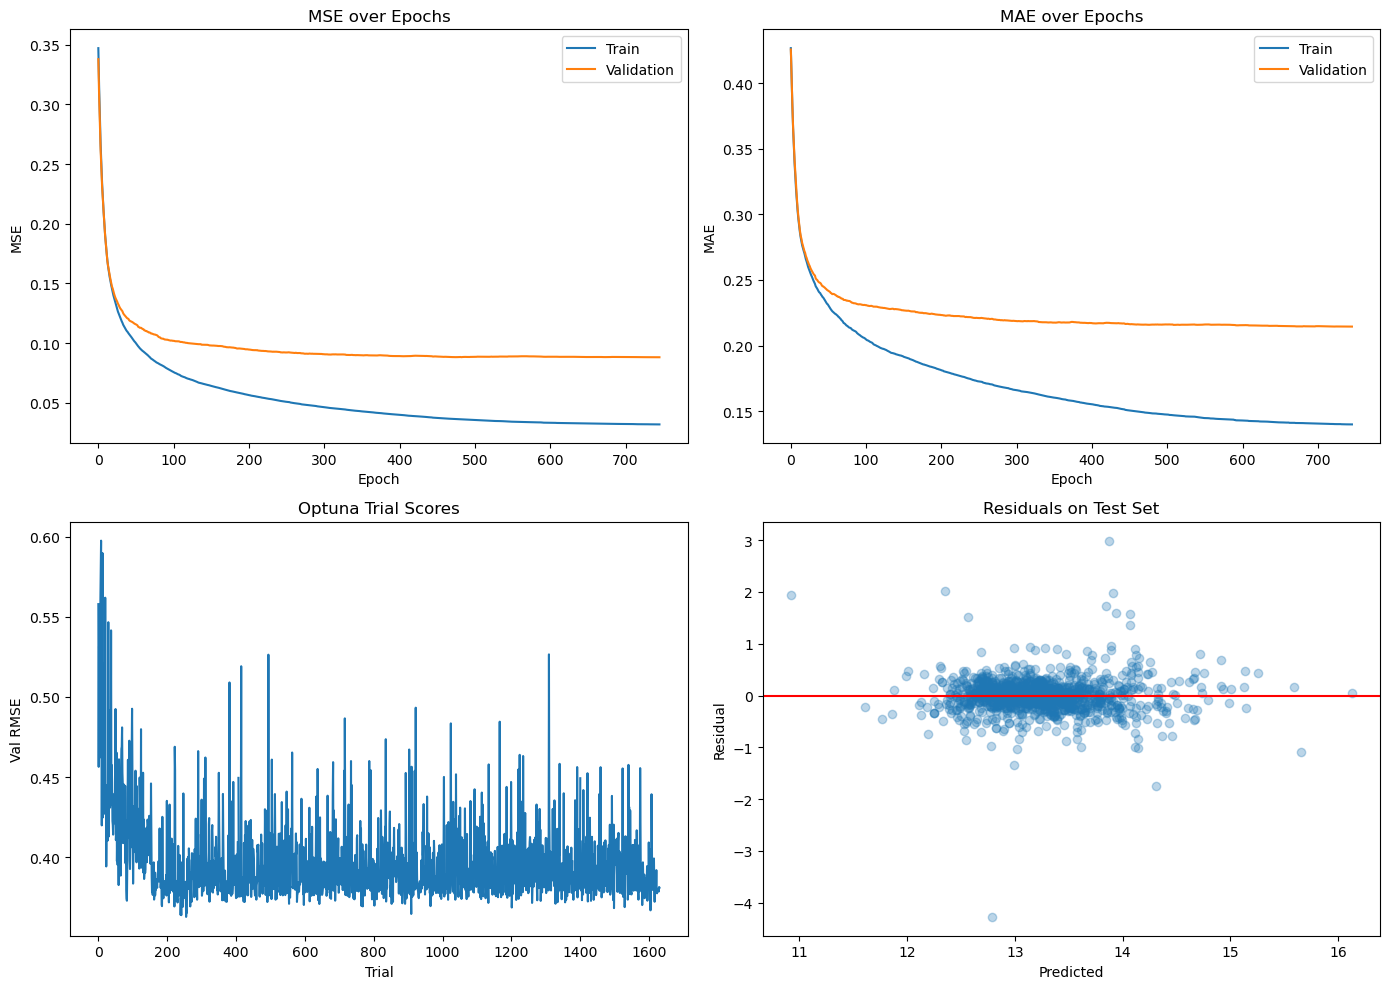

RMSE:          0.3531
MSE:           0.1247
MAE:           0.2257
R² (accuracy): 0.7021
Total Residual:261.8651


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Rebuild x with best max_features from study
best_max_features = study.best_trial.params['max_features']
vectorizer = TfidfVectorizer(max_features=best_max_features)

# Split structured and text separately to avoid leakage
structured = df1.drop(columns=["listPrice", "text"])
y = df1["listPrice"]

structured_train, structured_temp, Y_train, Y_temp = train_test_split(structured, y, test_size=0.3, random_state=42)
structured_val, structured_test, Y_val, Y_test = train_test_split(structured_temp, Y_temp, test_size=0.5, random_state=42)

# Fit vectoriser on training text only
text_train = vectorizer.fit_transform(df1.loc[structured_train.index, "text"])
text_val   = vectorizer.transform(df1.loc[structured_val.index, "text"])
text_test  = vectorizer.transform(df1.loc[structured_test.index, "text"])

X_train = hstack([csr_matrix(structured_train), text_train])
X_val   = hstack([csr_matrix(structured_val),   text_val])
X_test  = hstack([csr_matrix(structured_test),  text_test])

# Get metrics from model
train_rmse = np.array(best_results['validation_0']['rmse'])
val_rmse   = np.array(best_results['validation_1']['rmse'])
train_mae  = np.array(best_results['validation_0']['mae'])
val_mae    = np.array(best_results['validation_1']['mae'])

train_mse = train_rmse ** 2
val_mse   = val_rmse ** 2
epochs    = range(len(train_mse))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(epochs, train_mse, label='Train')
axes[0, 0].plot(epochs, val_mse,   label='Validation')
axes[0, 0].set_title('MSE over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].legend()

axes[0, 1].plot(epochs, train_mae, label='Train')
axes[0, 1].plot(epochs, val_mae,   label='Validation')
axes[0, 1].set_title('MAE over Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()

trial_values = [t.value for t in study.trials]
axes[1, 0].plot(trial_values)
axes[1, 0].set_title('Optuna Trial Scores')
axes[1, 0].set_xlabel('Trial')
axes[1, 0].set_ylabel('Val RMSE')

# Predictions - no inverse transform needed
predictions  = best_model.predict(X_test)
Y_test_actual = np.array(Y_test)

residuals = Y_test_actual - predictions
axes[1, 1].scatter(predictions, residuals, alpha=0.3)
axes[1, 1].axhline(0, color='red')
axes[1, 1].set_title('Residuals on Test Set')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

mse = mean_squared_error(Y_test_actual, predictions)
mae = mean_absolute_error(Y_test_actual, predictions)
r2  = r2_score(Y_test_actual, predictions)
total_residual = np.sum(np.abs(residuals))
print(f"RMSE:          {np.sqrt(mse):.4f}")
print(f"MSE:           {mse:.4f}")
print(f"MAE:           {mae:.4f}")
print(f"R² (accuracy): {r2:.4f}")
print(f"Total Residual:{total_residual:.4f}")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse   = mean_squared_error(Y_test, predictions)
mae   = mean_absolute_error(Y_test, predictions)
r2    = r2_score(Y_test, predictions)
total_residual = np.sum(np.abs(residuals))
print(f"RMSE:            {np.sqrt(mse):.4f}")
print(f"MSE:             {mse:.4f}")
print(f"MAE:             {mae:.4f}")
print(f"R² (accuracy):   {r2:.4f}")
print(f"Total Residual:  {total_residual:.4f}")


RMSE:            0.4136
MSE:             0.1711
MAE:             0.2700
R² (accuracy):   0.5912
Total Residual:  313.1861


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

filepath = r"C:\Users\lexwo\Downloads\cleaned_without.csv"
df1 = pd.read_csv(filepath)
df1["garage"] = df1["garage"].fillna(0)

# Split first
num_cols = ["sqft","stories","beds","baths","baths_full","baths_full_calc","year_built","garage"]

X = df1.drop(columns=["listPrice"])
y = df1["listPrice"]

X_train1, X_temp1, Y_train1, Y_temp1 = train_test_split(X, y, test_size=0.3, random_state=42)
X_val1, X_test1, Y_val1, Y_test1 = train_test_split(X_temp1, Y_temp1, test_size=0.5, random_state=42)

# Fit scaler on training set only, then transform all splits
scaler = MinMaxScaler()
X_train1[num_cols] = scaler.fit_transform(X_train1[num_cols])
X_val1[num_cols] = scaler.transform(X_val1[num_cols])
X_test1[num_cols] = scaler.transform(X_test1[num_cols])

joblib.dump(scaler, r"C:\Users\lexwo\Downloads\scalar2.pkl")



['C:\\Users\\lexwo\\Downloads\\scalar2.pkl']

In [7]:
def objective2(trial):
    params = {
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 0.5),
        'random_state': 42,
        'booster': 'gbtree',
        'device': 'cuda',
        'max_bin': 1024,
        'n_jobs': 2,
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'max_delta_step': trial.suggest_float('max_delta_step', 0.0, 10.0)
    }
    model = XGBRegressor(**params, early_stopping_rounds=50, eval_metric=['rmse', 'mae'])
    model.fit(X_train1, Y_train1, eval_set=[(X_train1, Y_train1), (X_val1, Y_val1)], verbose=False)
    results = model.evals_result()
    best_iter = model.best_iteration
    val_rmse   = results['validation_1']['rmse'][best_iter]
    val_mae    = results['validation_1']['mae'][best_iter]
    train_rmse = results['validation_0']['rmse'][best_iter]
    trial.set_user_attr('val_rmse', val_rmse)
    trial.set_user_attr('val_mae', val_mae)
    trial.set_user_attr('train_rmse', train_rmse)
    del model, results
    return val_rmse

def print_callback2(study, trial):
    print(f"Trial {trial.number} | train_rmse: {trial.user_attrs['train_rmse']:.4f} | val_rmse: {trial.user_attrs['val_rmse']:.4f}")

study2 = optuna.create_study(direction='minimize')
study2.optimize(objective2, n_trials=2000, callbacks=[print_callback2])


[I 2026-03-27 00:34:10,988] A new study created in memory with name: no-name-d3c8c84e-aa73-4e63-9a98-caac1f8dd35a
[I 2026-03-27 00:34:11,124] Trial 0 finished with value: 0.3812617110662669 and parameters: {'learning_rate': 0.17084858719827578, 'max_depth': 3, 'n_estimators': 378, 'subsample': 0.6637091027379567, 'colsample_bytree': 0.764085864673185, 'min_child_weight': 9, 'gamma': 0.469668248204782, 'reg_alpha': 0.6843136257396358, 'reg_lambda': 0.9823800379963711, 'max_delta_step': 2.294953719635644}. Best is trial 0 with value: 0.3812617110662669.
[I 2026-03-27 00:34:11,306] Trial 1 finished with value: 0.3756856829928544 and parameters: {'learning_rate': 0.13670214270591152, 'max_depth': 9, 'n_estimators': 343, 'subsample': 0.7610883663036458, 'colsample_bytree': 0.6969707707640922, 'min_child_weight': 7, 'gamma': 0.4886260254067626, 'reg_alpha': 0.8956772377825969, 'reg_lambda': 0.03372848827788, 'max_delta_step': 5.649163647824972}. Best is trial 1 with value: 0.3756856829928544

Trial 0 | train_rmse: 0.3629 | val_rmse: 0.3813
Trial 1 | train_rmse: 0.3324 | val_rmse: 0.3757


[I 2026-03-27 00:34:12,411] Trial 2 finished with value: 0.37992353033513204 and parameters: {'learning_rate': 0.018737222732855937, 'max_depth': 5, 'n_estimators': 681, 'subsample': 0.8803944050199817, 'colsample_bytree': 0.6208647527624979, 'min_child_weight': 3, 'gamma': 0.06628542473085458, 'reg_alpha': 0.49638583509887124, 'reg_lambda': 0.46621773286648427, 'max_delta_step': 0.3980783571902413}. Best is trial 1 with value: 0.3756856829928544.
[I 2026-03-27 00:34:12,618] Trial 3 finished with value: 0.37917654940027934 and parameters: {'learning_rate': 0.10331329196623616, 'max_depth': 10, 'n_estimators': 192, 'subsample': 0.7360351941274057, 'colsample_bytree': 0.6902617410809765, 'min_child_weight': 8, 'gamma': 0.2759730646734593, 'reg_alpha': 0.4793009439613267, 'reg_lambda': 0.4580234917672199, 'max_delta_step': 9.71919400163366}. Best is trial 1 with value: 0.3756856829928544.


Trial 2 | train_rmse: 0.3327 | val_rmse: 0.3799
Trial 3 | train_rmse: 0.3232 | val_rmse: 0.3792


[I 2026-03-27 00:34:12,843] Trial 4 finished with value: 0.3734221430204694 and parameters: {'learning_rate': 0.11990274485200576, 'max_depth': 6, 'n_estimators': 558, 'subsample': 0.8734915043968882, 'colsample_bytree': 0.5354507893919672, 'min_child_weight': 5, 'gamma': 0.24774221600933272, 'reg_alpha': 0.7095306144473799, 'reg_lambda': 0.11013947142849334, 'max_delta_step': 7.4108104362600375}. Best is trial 4 with value: 0.3734221430204694.
[I 2026-03-27 00:34:13,000] Trial 5 finished with value: 0.38040282029656325 and parameters: {'learning_rate': 0.19497452720661493, 'max_depth': 5, 'n_estimators': 299, 'subsample': 0.9852219826740776, 'colsample_bytree': 0.7338379365639136, 'min_child_weight': 2, 'gamma': 0.38937810679121626, 'reg_alpha': 0.5836278650566478, 'reg_lambda': 0.03306153771225828, 'max_delta_step': 3.95011129178946}. Best is trial 4 with value: 0.3734221430204694.


...

[I 2026-03-27 00:41:11,275] Trial 1086 finished with value: 0.3654852795525161 and parameters: {'learning_rate': 0.07148983765812934, 'max_depth': 10, 'n_estimators': 332, 'subsample': 0.9386799187339105, 'colsample_bytree': 0.8217576800346752, 'min_child_weight': 2, 'gamma': 0.2729770785853421, 'reg_alpha': 0.8718439908085136, 'reg_lambda': 0.018979590512668426, 'max_delta_step': 7.001461770887828}. Best is trial 675 with value: 0.3593797117220494.


Trial 1086 | train_rmse: 0.2959 | val_rmse: 0.3655


[I 2026-03-27 00:41:11,651] Trial 1087 finished with value: 0.35976378075077003 and parameters: {'learning_rate': 0.05747890468338917, 'max_depth': 10, 'n_estimators': 292, 'subsample': 0.9428656540356689, 'colsample_bytree': 0.8262823876510859, 'min_child_weight': 1, 'gamma': 0.2804542895254268, 'reg_alpha': 0.8389205113449965, 'reg_lambda': 0.05608685000679993, 'max_delta_step': 7.670243091950268}. Best is trial 675 with value: 0.3593797117220494.
[W 2026-03-27 00:41:11,661] Trial 1088 failed with parameters: {'learning_rate': 0.060943596960622605, 'max_depth': 10} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\lexwo\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\lexwo\AppData\Local\Temp\ipykernel_6540\413813089.py", line 5, in objective2
    'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
                        ~~~~~~~~~~~~~

Trial 1087 | train_rmse: 0.2935 | val_rmse: 0.3598


KeyboardInterrupt: 

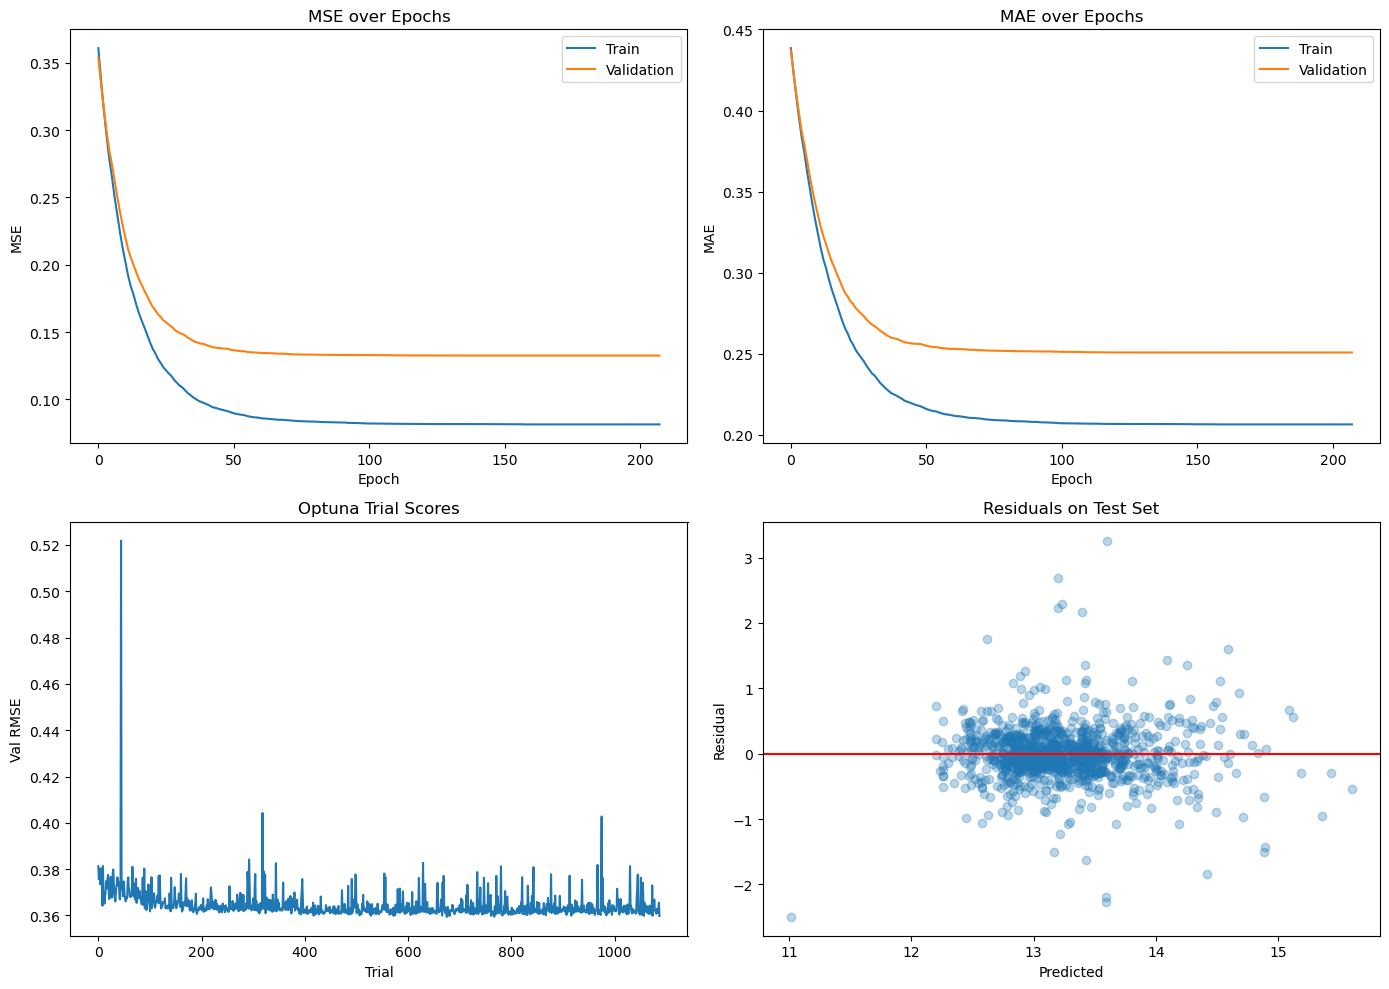

RMSE:          0.4153
MSE:           0.1725
MAE:           0.2758
R² (accuracy): 0.5878
Total Residual:319.9698


In [8]:
best_trial2 = study2.best_trial
best_params2 = best_trial2.params.copy()

# Recreate data for second dataset
structured = csr_matrix(df1.drop(columns=["listPrice"]))
y = df1["listPrice"]

X_train1, X_temp1, Y_train1, Y_temp1 = train_test_split(structured, y, test_size=0.3, random_state=42)
X_val1, X_test1, Y_val1, Y_test1 = train_test_split(X_temp1, Y_temp1, test_size=0.5, random_state=42)

best_model2 = XGBRegressor(**best_params2, early_stopping_rounds=50, eval_metric=['rmse', 'mae'])
best_model2.fit(X_train1, Y_train1, eval_set=[(X_train1, Y_train1), (X_val1, Y_val1)], verbose=False)
best_results2 = best_model2.evals_result()

# Get metrics directly from model
train_rmse = np.array(best_results2['validation_0']['rmse'])
val_rmse   = np.array(best_results2['validation_1']['rmse'])
train_mae  = np.array(best_results2['validation_0']['mae'])
val_mae    = np.array(best_results2['validation_1']['mae'])

train_mse = train_rmse ** 2
val_mse   = val_rmse ** 2

epochs = range(len(train_mse))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(epochs, train_mse, label='Train')
axes[0, 0].plot(epochs, val_mse,   label='Validation')
axes[0, 0].set_title('MSE over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].legend()

axes[0, 1].plot(epochs, train_mae, label='Train')
axes[0, 1].plot(epochs, val_mae,   label='Validation')
axes[0, 1].set_title('MAE over Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()

trial_values = [t.value for t in study2.trials]
axes[1, 0].plot(trial_values)
axes[1, 0].set_title('Optuna Trial Scores')
axes[1, 0].set_xlabel('Trial')
axes[1, 0].set_ylabel('Val RMSE')

# Predictions - no inverse transform needed
predictions2  = best_model2.predict(X_test1)
Y_test1_actual = np.array(Y_test1)

residuals = Y_test1_actual - predictions2
axes[1, 1].scatter(predictions2, residuals, alpha=0.3)
axes[1, 1].axhline(0, color='red')
axes[1, 1].set_title('Residuals on Test Set')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

mse  = mean_squared_error(Y_test1_actual, predictions2)
mae  = mean_absolute_error(Y_test1_actual, predictions2)
r2   = r2_score(Y_test1_actual, predictions2)
total_residual = np.sum(np.abs(residuals))
print(f"RMSE:          {np.sqrt(mse):.4f}")
print(f"MSE:           {mse:.4f}")
print(f"MAE:           {mae:.4f}")
print(f"R² (accuracy): {r2:.4f}")
print(f"Total Residual:{total_residual:.4f}")


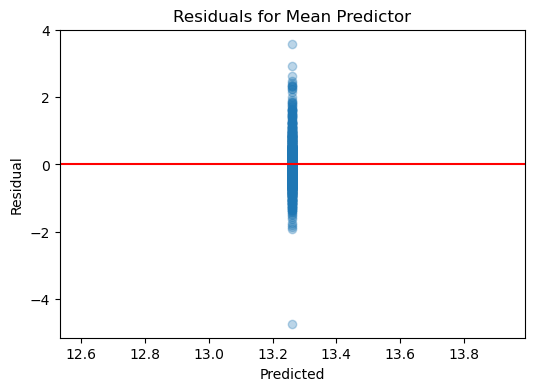

RMSE:          0.6472
MSE:           0.4188
MAE:           0.4660
R² (accuracy): -0.0008
Total Residual:540.5677
